In [28]:
from pathlib import Path
import uproot
from matplotlib import pyplot as plt
import numpy as np
import mplhep as hep

plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [53]:
figure_path = Path("figures")
figure_path.mkdir(parents=True, exist_ok=True)

LUMI_DICT = {
    "2022": 7.9804, 
    # "2022EE": 26.6717,
    "2022EE": 26.672,
    # "2023": 17.78937,
    "2023": 17.789,
    "2023BPix": 9.451,
}

In [54]:
from typing import Optional


def plot(era: str, region: str, bins: Optional[np.ndarray] = None, savepath: Optional[Path] = None):
    path = Path(f"output/efficiency_GloParT_{era}_{region}.root")
    file = uproot.open(str(path.resolve()))
    
    sf_hist = file["SF_TXbb"]
    sf_values = sf_hist.values()  # SF values
    weights = sf_hist.errors()    # Use errors as weights
    
    # plot
    plt.figure(figsize=(10, 8), dpi=100)

    hep.cms.label(
        "Preliminary",
        data=True,
        year=era,
        lumi=LUMI_DICT[era],
    )
    
    if bins is None:   
        bins=np.linspace(0, 2.0, 50)
    # Create the histogram
    plt.hist(sf_values, bins=bins, weights=weights, histtype='step')
    plt.xlabel("Trigger SF")
    plt.ylabel("Fraction of Events")
    
    if savepath is not None:
        plt.savefig(savepath)
    
    plt.show()

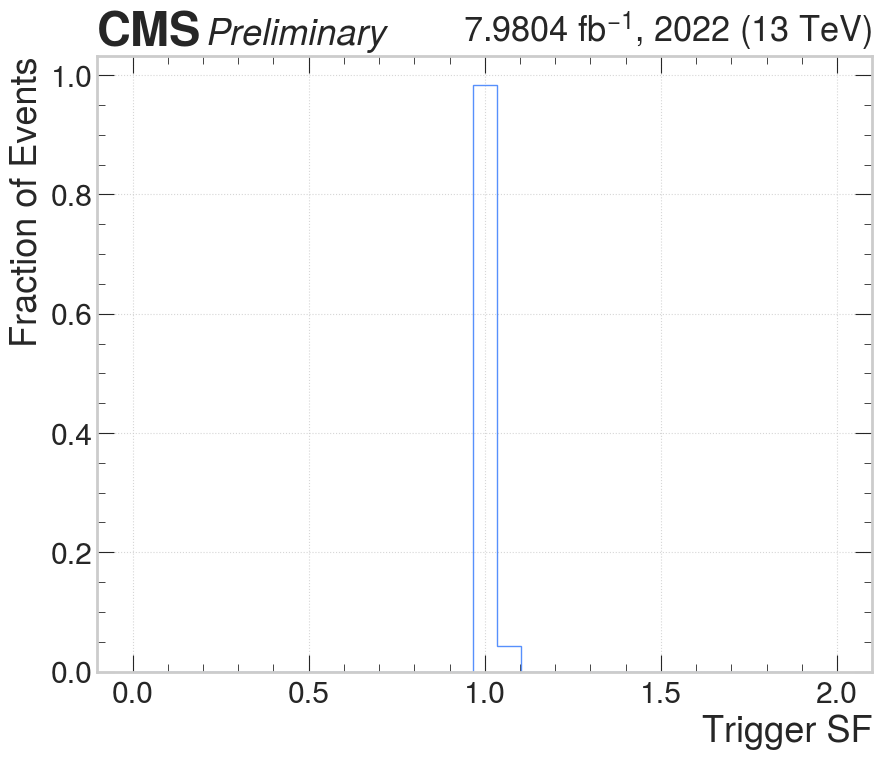

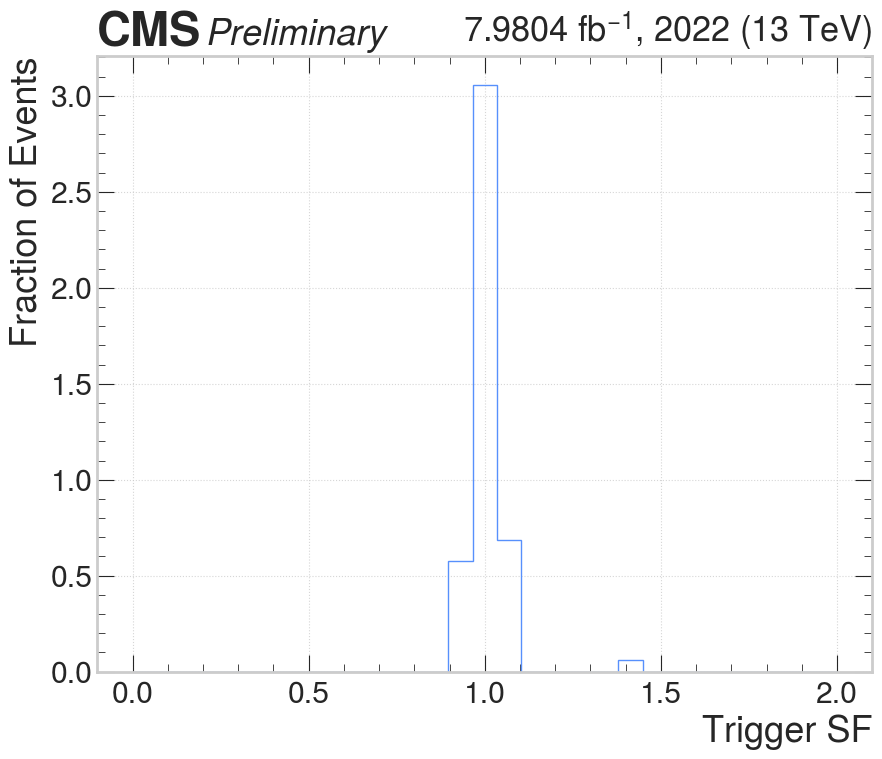

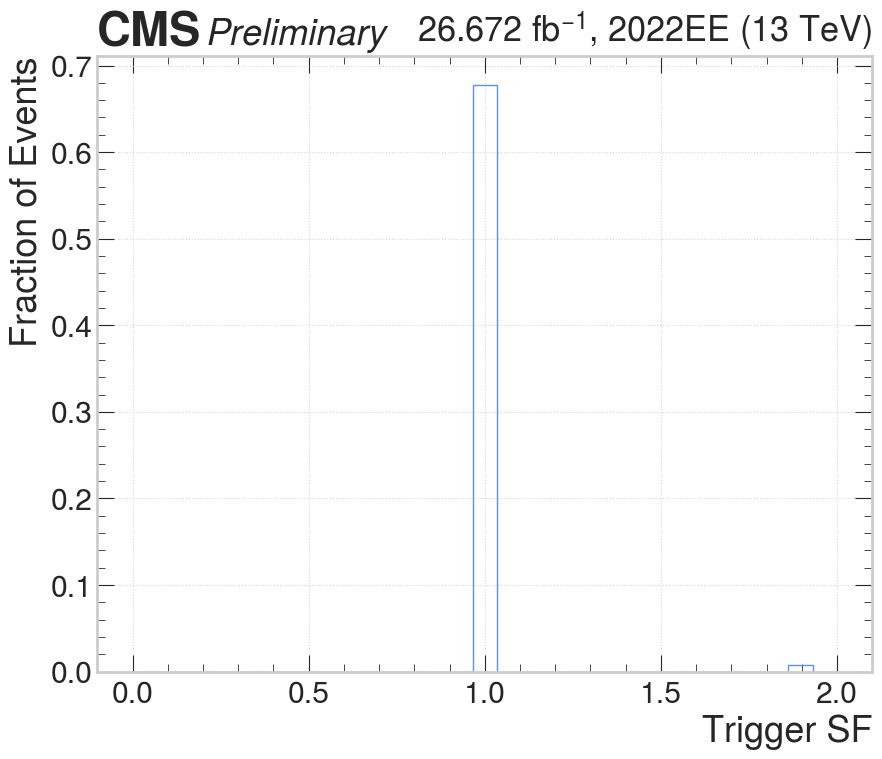

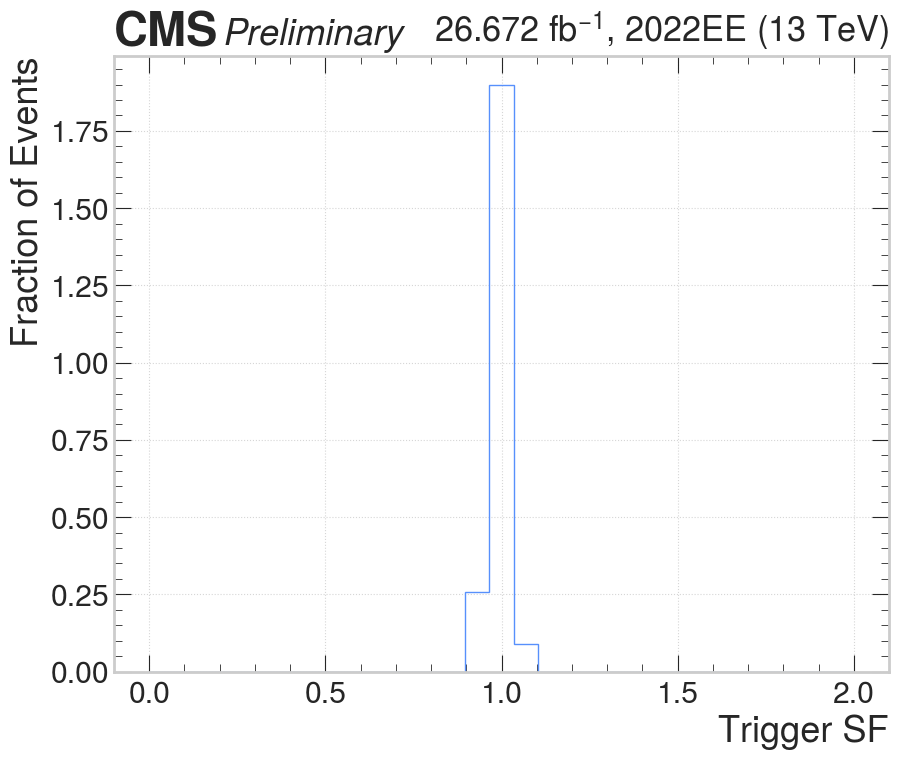

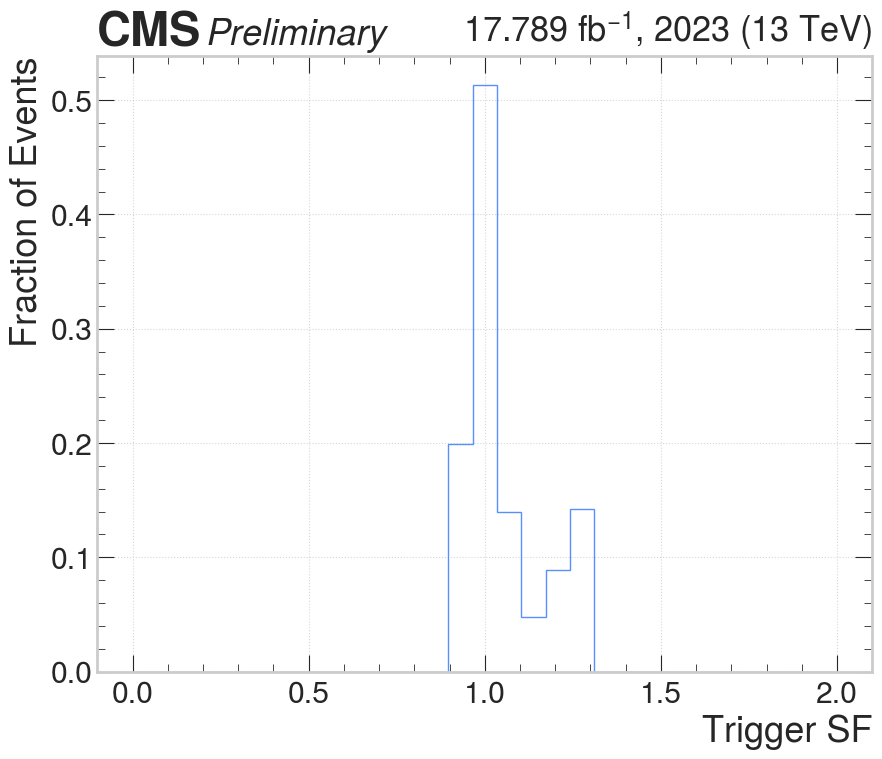

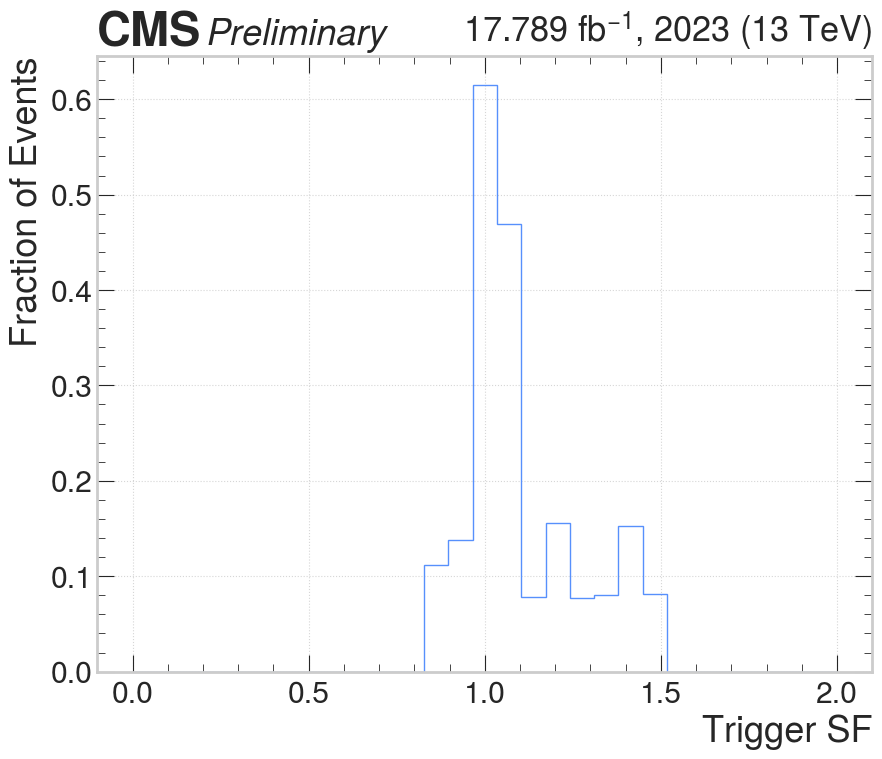

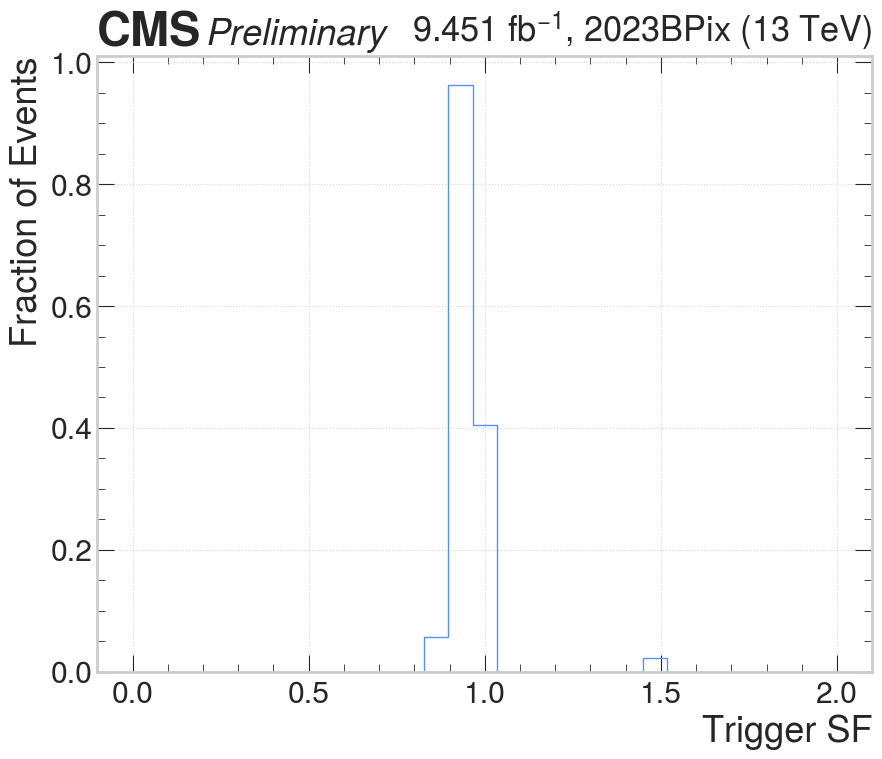

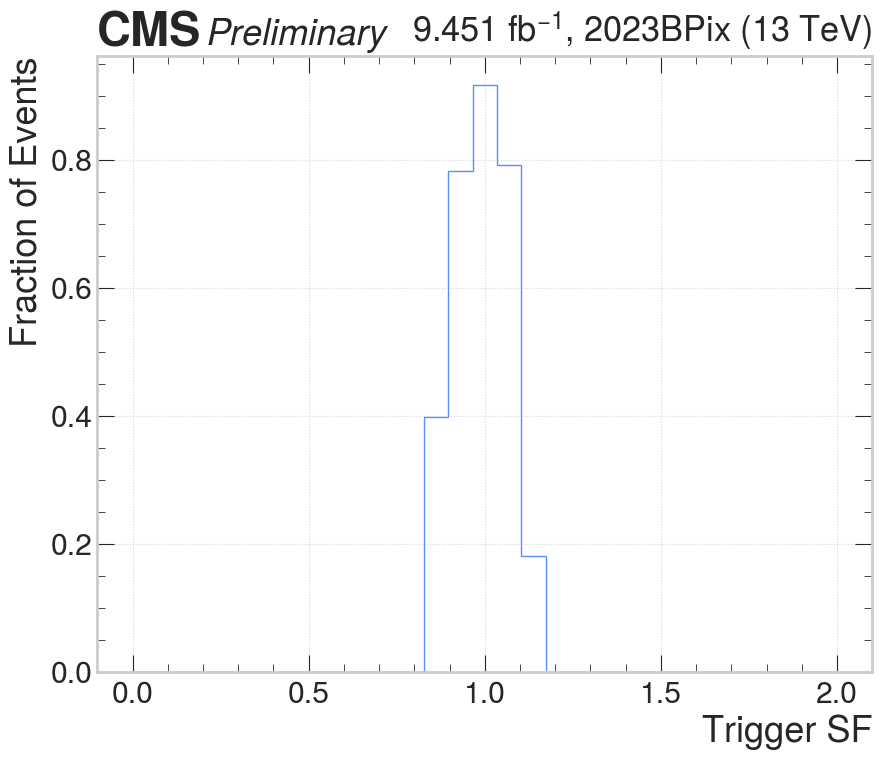

In [57]:
for era in LUMI_DICT.keys():
    for region in ("QCD", "TTbar"):
        savepath = figure_path / f"SF_hist_{era}_{region}.pdf"
        bins = np.linspace(0, 2.0, 30)
        plot(era=era, region=region, bins=bins, savepath=savepath)

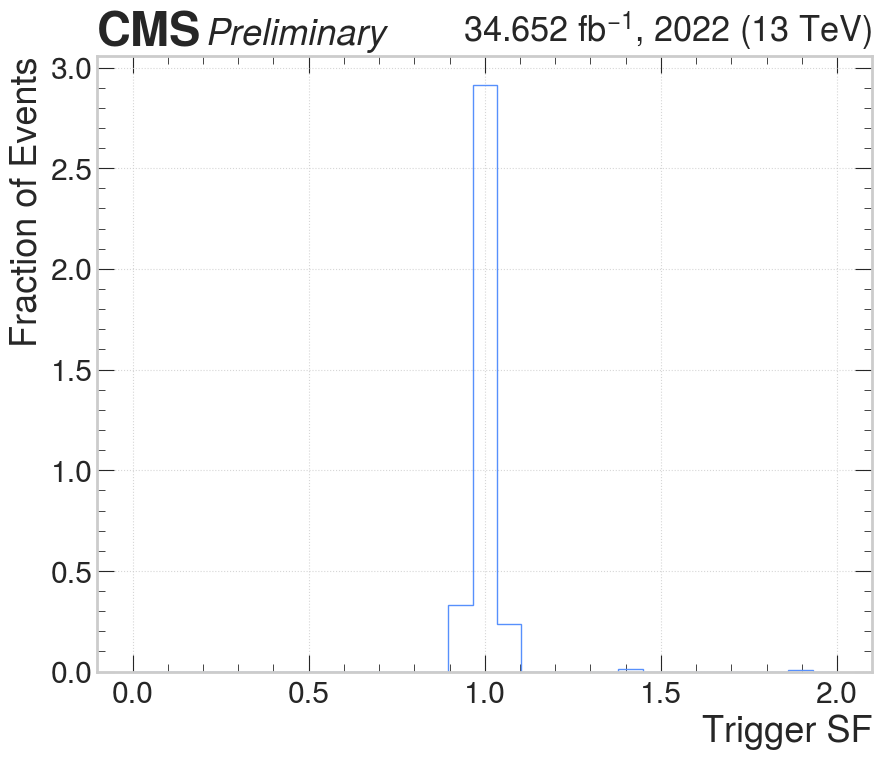

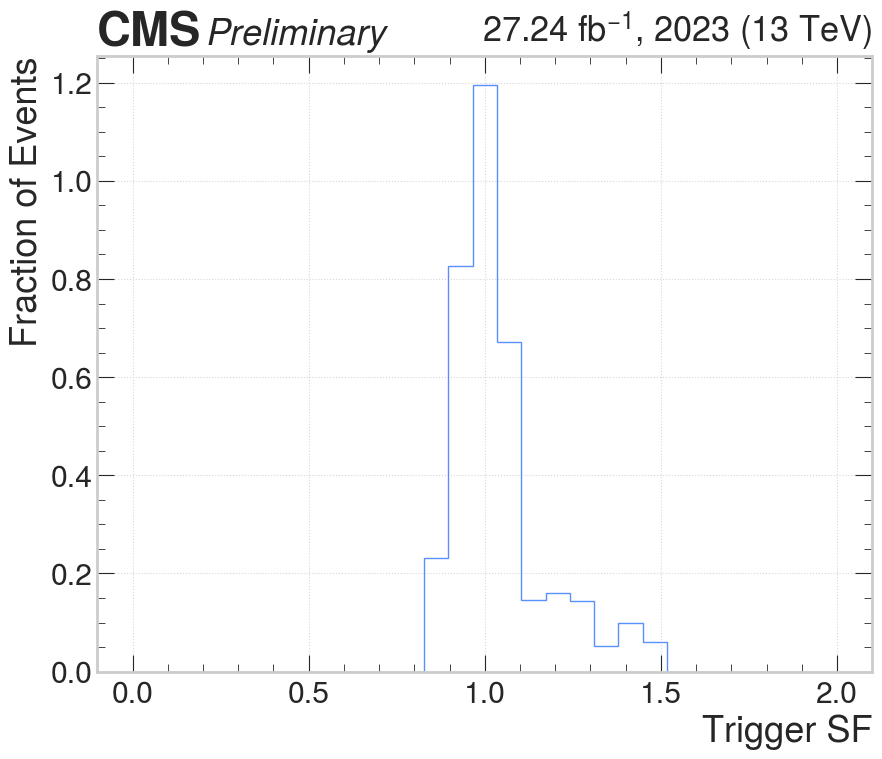

In [61]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import uproot
import mplhep as hep

figure_path = Path("figures")
figure_path.mkdir(parents=True, exist_ok=True)

LUMI_DICT = {
    "2022": 7.9804,
    "2022EE": 26.672,
    "2023": 17.789,
    "2023BPix": 9.451,
}

def get_histogram_data(era: str, region: str) -> tuple[np.ndarray, np.ndarray]:
    """Get SF values and weights from a ROOT file"""
    path = Path(f"output/efficiency_GloParT_{era}_{region}.root")
    file = uproot.open(str(path.resolve()))
    sf_hist = file["SF_TXbb"]
    return sf_hist.values(), sf_hist.errors()

def plot_combined(year_group: str, bins: np.ndarray, savepath: Optional[Path] = None):
    """
    Plot combined SF histograms for a given year group (2022+2022EE or 2023+2023BPix)
    
    Args:
        year_group: Either "2022" or "2023" to indicate which years to combine
        bins: Bin edges for histogram
        savepath: Optional path to save the figure
    """
    # Define which eras to combine based on year_group
    if year_group == "2022":
        eras = ["2022", "2022EE"]
        total_lumi = LUMI_DICT["2022"] + LUMI_DICT["2022EE"]
    elif year_group == "2023":
        eras = ["2023", "2023BPix"]
        total_lumi = LUMI_DICT["2023"] + LUMI_DICT["2023BPix"]
    else:
        raise ValueError(f"Unknown year group: {year_group}")

    # Lists to store combined data
    combined_sf_values = []
    combined_weights = []
    
    # Combine data from QCD and TTbar regions for each era
    for era in eras:
        for region in ("QCD", "TTbar"):
            sf_values, weights = get_histogram_data(era, region)
            
            # Weight the contribution by luminosity
            lumi_weight = LUMI_DICT[era] / total_lumi
            weighted_weights = weights * lumi_weight
            
            combined_sf_values.extend(sf_values)
            combined_weights.extend(weighted_weights)
    
    # Create plot
    plt.figure(figsize=(10, 8), dpi=100)
    
    # Add CMS label
    hep.cms.label(
        "Preliminary",
        data=True,
        year=year_group,
        lumi=round(total_lumi, 3),
    )
    
    # Plot histogram
    plt.hist(combined_sf_values, 
             bins=bins, 
             weights=combined_weights, 
             histtype='step',
             label=f'Combined {year_group}')
    
    plt.xlabel("Trigger SF")
    plt.ylabel("Fraction of Events")
    
    if savepath is not None:
        plt.savefig(savepath)
    
    plt.show()
    plt.close()

# Main execution

bins = np.linspace(0, 2.0, 30)

# Plot combined 2022 data
plot_combined(
    year_group="2022",
    bins=bins,
    savepath=figure_path / "SF_combined_hist_2022.pdf"
)

# Plot combined 2023 data
plot_combined(
    year_group="2023",
    bins=bins,
    savepath=figure_path / "SF_combined_hist_2023.pdf"
)